In [43]:
# imports that are required
import pandas as pd
import numpy as np

# imports that are required for creating visuals
import matplotlib.pyplot as plt
import seaborn as sns

# additional imports required for time series forecasting
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [44]:
# loading the house price data set into anaconda
df = pd.read_csv("Average-prices-Property-Type-2025-07.csv")

print("Data loaded successfully.\n")

#  code to get a preview of the first few rows
print(df.head())

Data loaded successfully.

         Date   Region_Name  Area_Code  Detached_Average_Price  \
0  1995-01-01       England  E92000001                 86969.0   
1  1995-01-01         Wales  W92000004                 66840.0   
2  1995-01-01  Inner London  E13000001                239573.0   
3  1995-01-01  Outer London  E13000002                172477.0   
4  1995-01-01        London  E12000007                176754.0   

   Detached_Index  Detached_Monthly_Change  Detached_Annual_Change  \
0            18.6                      NaN                     NaN   
1            20.9                      NaN                     NaN   
2            12.4                      NaN                     NaN   
3            15.2                      NaN                     NaN   
4            15.0                      NaN                     NaN   

   Semi_Detached_Average_Price  Semi_Detached_Index  \
0                      49270.0                 17.8   
1                      39500.0               

In [45]:
# cleaning up column names by removing additional spaces that may be before or after
df.columns = df.columns.str.strip()

# converting the Date column to the datetime format for the time series analysis
df['Date'] = pd.to_datetime(df['Date'])

In [46]:
print("\nmissing values checks")

print("Missing values in Date:", df['Date'].isnull().sum())
print("Missing values in Region:", df['Region_Name'].isnull().sum())
print("Missing values in Flat prices:", df['Flat_Average_Price'].isnull().sum())
print("Missing values in Detached prices:", df['Detached_Average_Price'].isnull().sum())
print("Missing values in Semi-detached prices:", df['Semi_Detached_Average_Price'].isnull().sum())
print("Missing values in Terraced prices:", df['Terraced_Average_Price'].isnull().sum())


missing values checks
Missing values in Date: 0
Missing values in Region: 0
Missing values in Flat prices: 0
Missing values in Detached prices: 367
Missing values in Semi-detached prices: 367
Missing values in Terraced prices: 256


In [47]:
print("\ndata types checks")

print("Data type of Detached prices:", df['Detached_Average_Price'].dtype)


data types checks
Data type of Detached prices: float64


In [48]:
print("\nzero or negative price checks")

# Prices shouldn't be zero or negative, so check each column
flat_check = (df['Flat_Average_Price']<= 0).sum()
detached_check = (df['Detached_Average_Price']<= 0).sum()
semi_check = (df['Semi_Detached_Average_Price']<= 0).sum()
terraced_check = (df['Terraced_Average_Price']<= 0).sum()

print("Flats <= 0:",flat_check)
print("Detached <= 0:",detached_check)
print("Semidetached <= 0:",semi_check)
print("Teraced <= 0:",terraced_check)


zero or negative price checks
Flats <= 0: 0
Detached <= 0: 0
Semidetached <= 0: 0
Teraced <= 0: 0


In [49]:
print("\nduplicate row checks")

# count of how many duplicate rows exist
duplicates = df.duplicated().sum()

print("number of duplicate rows:", duplicates)


duplicate row checks
number of duplicate rows: 0


In [50]:
print("\nprice logic check (checking avg detached are higher than avg flats)")

# Compare average prices between property types
avg_flat = df['Flat_Average_Price'].mean()
avg_detached = df['Detached_Average_Price'].mean()

print("Average flat price:", round(avg_flat, 2))
print("Average detached price:", round(avg_detached, 2))


price logic check (checking avg detached are higher than avg flats)
Average flat price: 120491.09
Average detached price: 338756.57


In [51]:
print("\nregional price comparison")

# Work out average flat prices by region
regional_prices = df.groupby('Region_Name')['Flat_Average_Price'].mean()

# Sort from highest to lowest so it's easier to compare
regional_prices = regional_prices.sort_values(ascending=False)

print("\nTop 5 most expensive regions:")
print(regional_prices.head())

print("\nBottom 5 cheapest regions:")
print(regional_prices.tail())


regional price comparison

Top 5 most expensive regions:
Region_Name
Kensington and Chelsea    752433.138965
City of Westminster       604296.280654
City of London            495140.100817
Camden                    451478.640327
Hammersmith and Fulham    421689.604905
Name: Flat_Average_Price, dtype: float64

Bottom 5 cheapest regions:
Region_Name
Neath Port Talbot    50403.629428
Rhondda Cynon Taf    50033.544959
Burnley              48913.514986
Blaenau Gwent        47532.452316
Merthyr Tydfil       41724.692098
Name: Flat_Average_Price, dtype: float64


In [52]:
# cleaning the price columns (missing values removal)
price_cols = [
    "Detached_Average_Price",
    "Semi_Detached_Average_Price",
    "Terraced_Average_Price",
    "Flat_Average_Price"
]

# removing any rows where the price data is missing
df = df.dropna(subset=price_cols)

# checking code is working
print("\nChecking for missing values after cleaning:")

print(df[price_cols].isnull().sum())


Checking for missing values after cleaning:
Detached_Average_Price         0
Semi_Detached_Average_Price    0
Terraced_Average_Price         0
Flat_Average_Price             0
dtype: int64


In [53]:
# filter the dataset by solihull
solihull_df = df[df['Region_Name'] == 'Solihull'].copy()

# check to make sure the filtering worked
print("\nPreview of Solihull data:")

print(solihull_df.head())


Preview of Solihull data:
           Date Region_Name  Area_Code  Detached_Average_Price  \
94   1995-01-01    Solihull  E08000029                120461.0   
431  1995-02-01    Solihull  E08000029                119147.0   
792  1995-03-01    Solihull  E08000029                120391.0   
1171 1995-04-01    Solihull  E08000029                120055.0   
1534 1995-05-01    Solihull  E08000029                120091.0   

      Detached_Index  Detached_Monthly_Change  Detached_Annual_Change  \
94              20.4                      NaN                     NaN   
431             20.2                     -1.1                     NaN   
792             20.4                      1.0                     NaN   
1171            20.3                     -0.3                     NaN   
1534            20.4                      0.0                     NaN   

      Semi_Detached_Average_Price  Semi_Detached_Index  \
94                        64160.0                 18.9   
431                  

In [54]:
# Sort by actual Date column (not index)
solihull_df = solihull_df.sort_values('Date')

# Set Date as the index (this is REQUIRED for time series + forecasting)
solihull_df = solihull_df.set_index('Date')

# Optional but strongly recommended: enforce monthly frequency
solihull_df = solihull_df.asfreq('MS')

# Selecting the detached house prices as the column
ts = solihull_df['Detached_Average_Price']

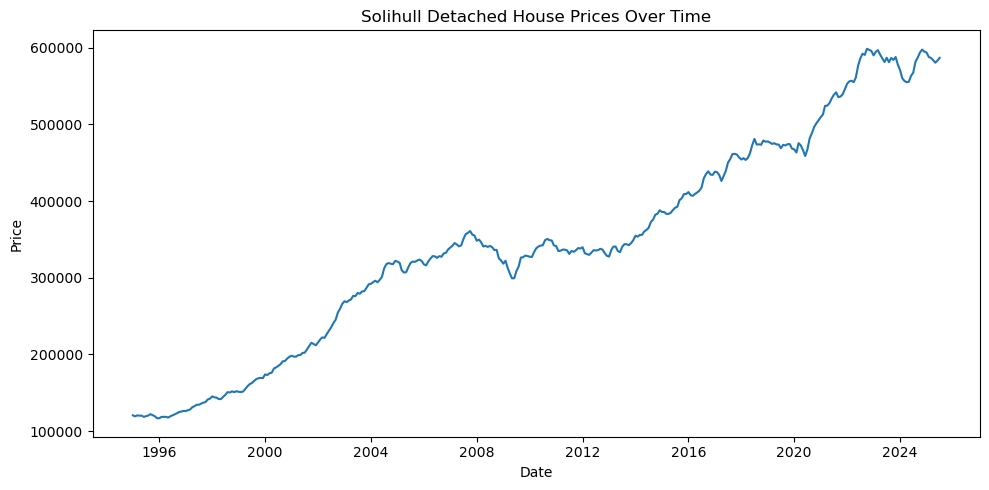

In [55]:
# creating a canvas for the time series graph
plt.figure(figsize=(10, 5))

# plotting the detached house price time series
plt.plot(ts)

# adding title and axis labels
plt.title("Solihull Detached House Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")

# adjusting layout so the labels wont overlap
plt.tight_layout()

# displaying the plot
plt.show()

In [56]:
# removing missing values (this is required before checking how stationary the data is)
clean_series = ts.dropna()

In [57]:
# fitting the sarima model
model = SARIMAX(ts, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit()

In [58]:
# generating a forecast for the next 120 months (10yr) period
forecast = model_fit.get_forecast(steps=120)

In [63]:
# get the last observed date from the time series
last_date = ts.index[-1]

# create a range of future monthly dates starting from next month
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=120,
    freq='MS'
)

In [64]:
# converting forecast output into a pandas series with the proper dates
forecast_series = forecast.predicted_mean
forecast_series.index = future_dates

In [65]:
print(forecast_series)

2025-08-01    595140.595434
2025-09-01    598754.304153
2025-10-01    602808.708128
2025-11-01    605278.742911
2025-12-01    603615.049159
                  ...      
2035-03-01    748623.859934
2035-04-01    747187.923725
2035-05-01    747416.750314
2035-06-01    750415.115353
2035-07-01    754699.983786
Freq: MS, Name: predicted_mean, Length: 120, dtype: float64


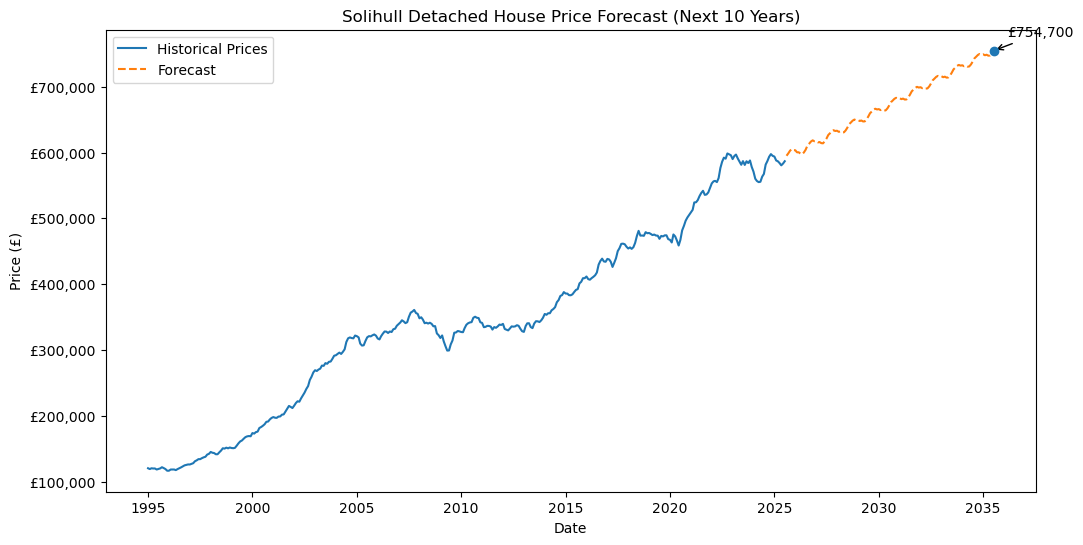

In [66]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

# plotting the historical data
plt.plot(ts, label="Historical Prices")

# plotting the forecast
plt.plot(forecast_series, label="Forecast", linestyle='--')

# formatting the y-axis with full values (for example 200,000)
ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x:,.0f}')
)

# annotatting the forecast value for 2035

# getting all forecast points in 2035
forecast_2035 = forecast_series[forecast_series.index.year == 2035]

# taking the last available point in 2035
x_2035 = forecast_2035.index[-1]
y_2035 = forecast_2035.iloc[-1]

# plotting a marker on the chart
plt.scatter(x_2035, y_2035, zorder=5)

# adding annotations
plt.annotate(f'£{y_2035:,.0f}',
             xy=(x_2035, y_2035),
             xytext=(10, 10),
             textcoords='offset points',
             arrowprops=dict(arrowstyle='->'))

# labels and titles
plt.title("Solihull Detached House Price Forecast (Next 10 Years)")
plt.xlabel("Date")
plt.ylabel("Price (£)")

plt.legend()
plt.show()